#1: project setup and data preprocessing

In [20]:

import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Loading the data into the columns
columns = ['age', 'class_of_worker', 'detailed_industry_recode', 'detailed_occupation_recode', 'education', 
    'wage_per_hour', 'enroll_in_edu_last_wk', 'marital_status', 'major_industry_code', 'major_occupation_code',
    'race', 'hispanic_origin', 'sex', 'member_of_labor_union', 'reason_for_unemployment', 
    'full_or_part_time_employment_status', 'capital_gains', 'capital_losses', 'dividends_from_stocks', 
    'tax_filer_status', 'region_of_previous_residence', 'state_of_previous_residence', 'detailed_household_and_family_status', 
    'detailed_household_summary_in_household', 'migration_code_change_in_msa', 'migration_code_change_in_region', 
    'migration_code_move_within_region', 'lived_in_house_1_year_ago', 'migration_prev_res_in_sunbelt', 
    'num_persons_worked_for_employer', 'family_members_under_18', 'country_of_birth_father', 'country_of_birth_mother', 
    'country_of_birth_self', 'citizenship', 'own_business_or_self_employed', 'fill_inc_questionnaire_for_veterans_admin', 
    'veterans_benefits', 'weeks_worked_in_year', 'year', 'income'
]

# Read in the income data and deal with the inital spaces in the data 
income_data = pd.read_csv("census-income.data", header=None, names=columns, skipinitialspace=True)

# Handle missing values by dropping rows with any missing values
income_data = income_data.dropna()

# seperate the categorial columns to avoid errors with strings and nums
categorical_columns = income_data.select_dtypes(include=['object']).columns.tolist()

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply Label Encoding to all categorical columns
for col in categorical_columns:
    income_data[col] = label_encoder.fit_transform(income_data[col])

#print 
print(income_data.head())


    age  class_of_worker  detailed_industry_recode  \
73    3                0                         0   
58    6                4                        34   
18    3                0                         0   
9     3                0                         0   
10    3                0                         0   

    detailed_occupation_recode  education  wage_per_hour  \
73                          12          0              2   
58                          16          0              2   
18                           0          0              1   
9                           10          0              2   
10                          10          0              2   

    enroll_in_edu_last_wk  marital_status  major_industry_code  \
73                      6              14                    6   
58                      0               4                    8   
18                      4              14                    6   
9                       4              14         

2:Split the data and training our model

In [24]:
# Using Given libs to split data into training:validation sets at a 70:30 ratio and eval the model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
# divinding the feature and labels
X = income_data.drop('income', axis=1)
y = income_data['income']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train the Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

#Giving the tree a max depth of 3
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

#eval the model
y_pred_val = clf.predict(X_val)
accuracy_val = accuracy_score(y_val, y_pred_val)
print(f"\nAccuracy on valid_set: {accuracy_val:.4f}")
print(classification_report(y_val, y_pred_val))



Accuracy on valid_set: 0.9442
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     55897
           1       0.69      0.18      0.29      3698

    accuracy                           0.94     59595
   macro avg       0.82      0.59      0.63     59595
weighted avg       0.93      0.94      0.93     59595



3: Make the Data Tree and visualize it 

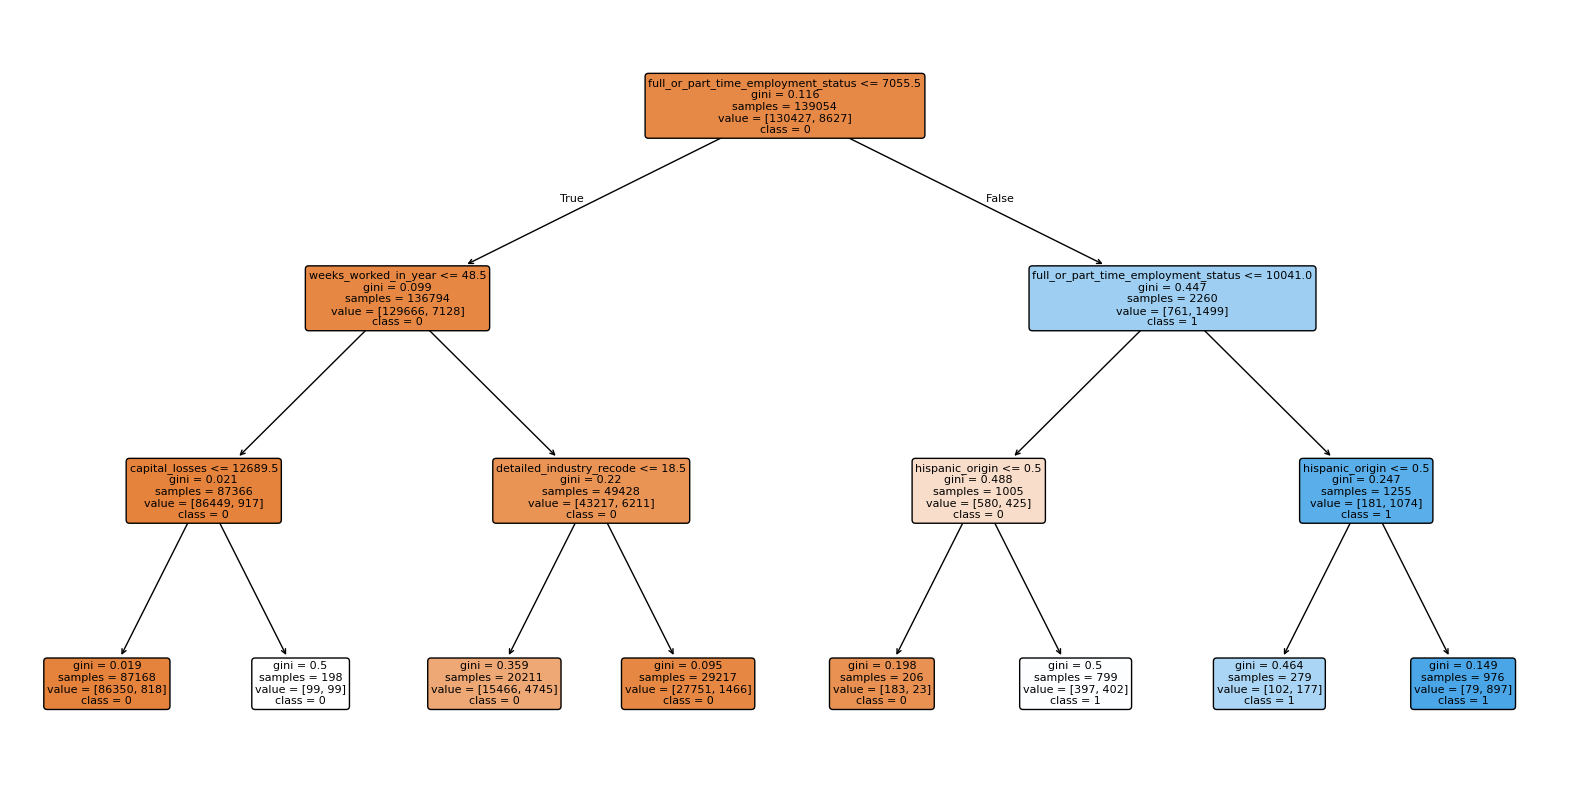

In [21]:
#our tree imports
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Visualization of the data tree
plt.figure(figsize=(20, 10))
plot_tree(
    clf, 
    feature_names=X.columns, 
    class_names=clf.classes_.astype(str), 
    filled=True, 
    rounded=True,
    fontsize=8
)
plt.show()


4:Feature Importance 


 Best 5 features:
                                Feature  Importance
15  full_or_part_time_employment_status    0.505143
38                 weeks_worked_in_year    0.226179
2              detailed_industry_recode    0.219932
17                       capital_losses    0.025689
11                      hispanic_origin    0.023057


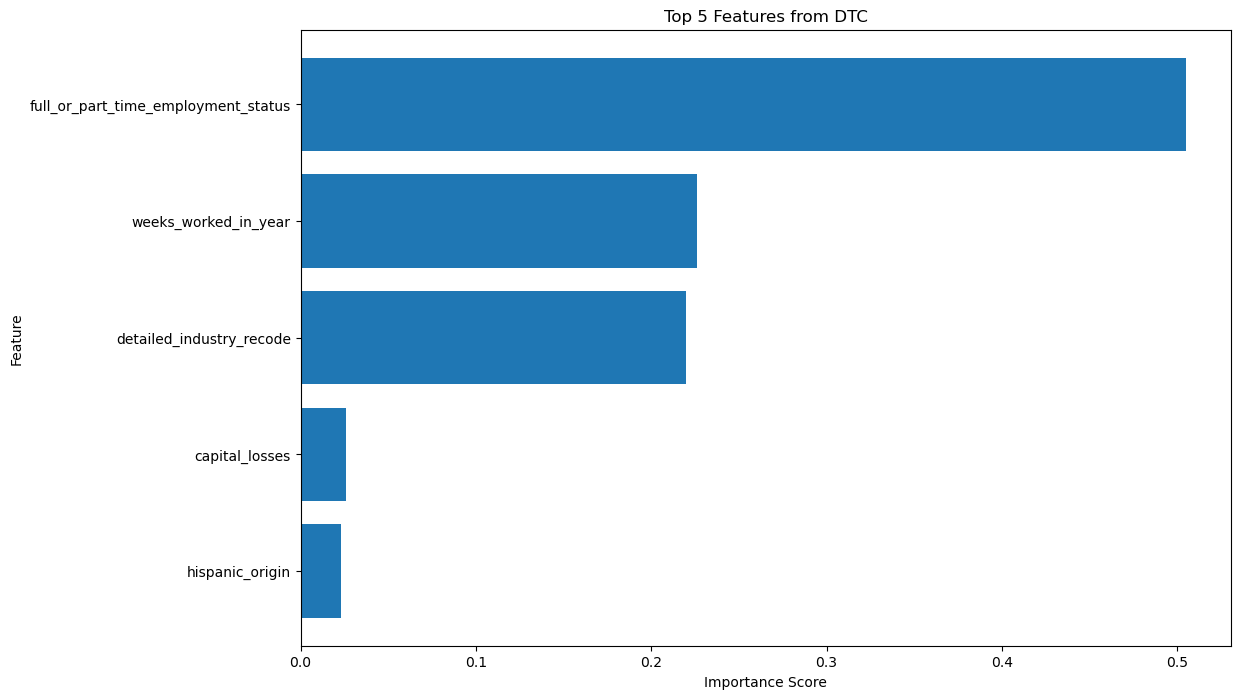

In [29]:
# splitting the features away
importances = clf.feature_importances_

#new DF for our visualization
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("\n Best 5 features:")
print(feature_importance_df.head(5))

# Visualize Feature Importances
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['Feature'][:5], feature_importance_df['Importance'][:5])
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 5 Features from DTC')
plt.gca().invert_yaxis()
plt.show()


#why these features:
In practice, you should fit the LabelEncoder on the training data and transform both training and test data using this fitted encoder to ensure consistency.
For multiple categorical columns, consider using sklearn.preprocessing.OrdinalEncoder.
Class Imbalance:

The dataset is imbalanced with a majority of instances in one class.
This may result in high accuracy but poor performance on the minority class.
Consider techniques like resampling or adjusting class weights to address this.
Model Performance:

With max_depth=3, the Decision Tree is shallow. Increasing the depth may improve performance but can also lead to overfitting.
Experiment with different depths and evaluate the impact on validation and test performance.
Interpreting Results:

Analyze the classification reports to understand precision, recall, and F1-score for each class.
Pay attention to any warnings about ill-defined metrics, which may indicate that the model is not predicting certain classes.
